In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional

In [10]:
def update_model(theta, z, loss, eta=0.1):
    theta.requires_grad_(True)
    theta.grad = None
    
    # Compute loss and gradient
    l_t = loss(z, theta)
    l_t.backward()
    dL1 = theta.grad

    with torch.no_grad(): # Update theta
        theta = theta - eta * dL1
    
    return theta.detach()

def RGD(
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    poison_function: Optional[Callable] = None,
    n: int = 1000,
    eta: float = 0.1,
    max_iter: int = 100,
    theta_min = None, 
    theta_max = None,
    **poison_kwargs
):

    all_thetas = []
    all_losses = []

    theta_t = theta_0
    t = 0
    
    while t < max_iter:
        
        # Draw n samples from D(theta)
        z = D_theta(theta_t, n)

        if poison_function is not None:
            z = poison_function(z, theta_t, loss=loss, eta=eta, **poison_kwargs)

        # Compute gradient of loss (dL1)
        theta_t.requires_grad_(True)
        theta_t.grad = None
        
        # Compute loss and gradient
        l_t = loss(z, theta_t)
        l_t.backward()
        dL1 = theta_t.grad

        with torch.no_grad(): # Update theta
            theta_t = theta_t - eta * dL1

        theta_t = theta_t.clamp(theta_min, theta_max) if (theta_min is not None and theta_max is not None) else theta_t

        # Check for NaNs in theta_t or z (supports torch.Tensor and numpy arrays)
        nan_in_theta = torch.isnan(theta_t).any().item() if isinstance(theta_t, torch.Tensor) else np.isnan(theta_t).any()
        if nan_in_theta:
            print(f"NaN detected in theta_t at iteration {t}. Stopping optimization.")
            break

        nan_in_z = torch.isnan(z).any().item() if isinstance(z, torch.Tensor) else np.isnan(z).any()
        if nan_in_z:
            print(f"NaN detected in z at iteration {t}. Stopping optimization.")
            break
            
        # Record loss on TRUE (not poisoned) distribution
        z_true = D_theta(theta_t, n)
        all_losses.append(l_t.item())
        all_thetas.append(theta_t.detach().squeeze())
        
        t += 1
    
    return theta_t, all_thetas, all_losses

def oracle_poison_function(
    z: torch.Tensor, 
    theta: torch.Tensor, 
    theta_update_estimator: Callable,
    mu: Callable,
    sigma: torch.Tensor,
    loss: Callable,
    eta: float,
    num_steps: int = 10, 
    step_size: float = 0.1, 
    epsilon: float = 1e-6,
    norm = 'linf', # 'l2' or 'linf'
    ):
    
    z_0 = z.clone().detach()
    for _ in range(num_steps): 
       
        z.requires_grad_(True)
        z.grad = None

        theta_new = theta_update_estimator(z, theta, eta, loss)
        assert theta_new.shape == theta.shape, "Shape mismatch in theta update estimator."

        mu_new = mu(theta_new)
        assert mu_new.shape == z.shape[:1], f"Shape mismatch in mu function: expected {z.shape[0]}, got {mu_new.shape}."
        
        z_new = mu_new.unsqueeze(-1) + sigma @ torch.randn_like(z)
        assert z_new.shape == z.shape, f"Shape mismatch in z_new: expected {z.shape}, got {z_new.shape}."
        
        l_theta = loss(z_new, theta_new)
        
        l_theta.backward()
        dz = z.grad
        
        with torch.no_grad():
            z += step_size * dz / (torch.norm(dz, dim=0, keepdim=True) + 1e-16)
            delta = z - z_0
            if norm == 'l2':
                delta_norm = torch.norm(delta, p=2, dim=0, keepdim=True) + 1e-16
                exceed_mask = (delta_norm > epsilon).float()
                delta = delta * (epsilon / delta_norm) * exceed_mask + delta * (1 - exceed_mask)
            elif norm == 'linf':
                delta_norm = torch.max(torch.abs(delta), dim=0, keepdim=True)[0] + 1e-16
                exceed_mask = (delta_norm > epsilon).float()
                delta = delta * (epsilon / delta_norm) * exceed_mask + delta * (1 - exceed_mask)
            assert delta.shape == z.shape, f"Shape mismatch in delta: expected {z.shape}, got {delta.shape}."
            z = z_0 + delta
            
    return z.detach()

def theta_update_estimator(z, theta, eta, loss):
    theta.requires_grad_(True)
    theta.grad = None
    
    # Compute loss and gradient
    l_t = loss(z, theta).mean(dim=-1)
    dL1 = torch.autograd.grad(l_t, theta, create_graph=True)[0]
    
    # Update theta
    theta_new = theta - eta * dL1

    return theta_new

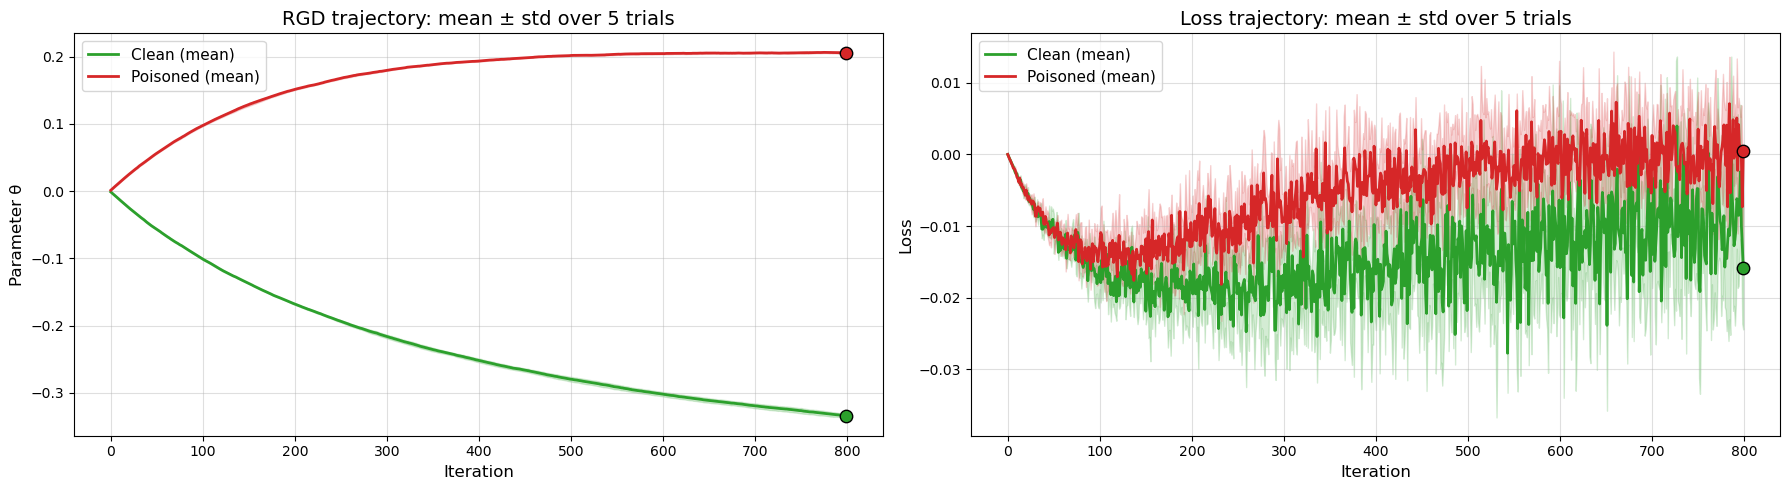

In [4]:
a0 = 1.0
a1 = 0.5
sigma = torch.tensor([[1.0]])
mu = lambda theta:(a0*theta + a1)**2
D_theta = lambda theta, n: torch.normal(mu(theta).squeeze(), 1.0, size=(1,n))
loss = lambda z, theta: (z*theta).mean(-1)


poison_kwargs = {
    'num_steps': 20,
    'step_size': 0.1,
    'epsilon': 5e-1,
    'norm': 'l2',
    'theta_update_estimator': theta_update_estimator,
    'mu': mu,
}

theta_0=torch.tensor([0.0])
n_trials = 5
n = 1000
eta = 0.005

def run_trial():

    _, all_theta_clean, all_loss_clean = RGD(
        D_theta=D_theta,
        loss=loss,
        sigma=sigma,
        theta_0=theta_0.clone(),
        n=n,
        eta=eta,
        max_iter=800,
        poison_function=None
    )
    _, all_theta_poisoned, all_loss_poisoned = RGD(
        D_theta=D_theta,
        loss=loss,
        sigma=sigma,
        theta_0=theta_0.clone(),
        n=n,
        eta=eta,
        max_iter=800,
        poison_function=oracle_poison_function,
        **poison_kwargs
    )
    
    return all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean)
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

# Aggregate across trials and plot mean ± std
def to_float_array(traj):
    return torch.tensor([t.item() if hasattr(t, "item") else float(t) for t in traj], dtype=torch.float32)

clean_stack = torch.stack([to_float_array(traj) for traj in all_theta_clean_list])      # [n_trials, T]
poison_stack = torch.stack([to_float_array(traj) for traj in all_theta_poisoned_list])  # [n_trials, T]

clean_mean = clean_stack.mean(dim=0).numpy()
clean_std  = clean_stack.std(dim=0, unbiased=False).numpy()
poison_mean = poison_stack.mean(dim=0).numpy()
poison_std  = poison_stack.std(dim=0, unbiased=False).numpy()

# Also process loss trajectories
loss_clean_stack = torch.stack([to_float_array(traj) for traj in all_loss_clean_list])      # [n_trials, T]
loss_poison_stack = torch.stack([to_float_array(traj) for traj in all_loss_poisoned_list])  # [n_trials, T]

loss_clean_mean = loss_clean_stack.mean(dim=0).numpy()
loss_clean_std  = loss_clean_stack.std(dim=0, unbiased=False).numpy()
loss_poison_mean = loss_poison_stack.mean(dim=0).numpy()
loss_poison_std  = loss_poison_stack.std(dim=0, unbiased=False).numpy()

x = np.arange(clean_mean.shape[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,5))

# Plot parameter trajectories
ax1.plot(x, clean_mean, label='Clean (mean)', color='tab:green', linewidth=2)
ax1.fill_between(x, clean_mean - clean_std, clean_mean + clean_std, color='tab:green', alpha=0.2)

ax1.plot(x, poison_mean, label='Poisoned (mean)', color='tab:red', linewidth=2)
ax1.fill_between(x, poison_mean - poison_std, poison_mean + poison_std, color='tab:red', alpha=0.2)

ax1.scatter(x[-1], clean_mean[-1], color='tab:green', edgecolor='k', s=80, zorder=5)
ax1.scatter(x[-1], poison_mean[-1], color='tab:red', edgecolor='k', s=80, zorder=5)

ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Parameter θ', fontsize=12)
ax1.set_title(f'RGD trajectory: mean ± std over {clean_stack.shape[0]} trials', fontsize=14)
ax1.legend(loc='best', fontsize=11)
ax1.grid(alpha=0.4)

# Plot loss trajectories
ax2.plot(x, loss_clean_mean, label='Clean (mean)', color='tab:green', linewidth=2)
ax2.fill_between(x, loss_clean_mean - loss_clean_std, loss_clean_mean + loss_clean_std, color='tab:green', alpha=0.2)

ax2.plot(x, loss_poison_mean, label='Poisoned (mean)', color='tab:red', linewidth=2)
ax2.fill_between(x, loss_poison_mean - loss_poison_std, loss_poison_mean + loss_poison_std, color='tab:red', alpha=0.2)

ax2.scatter(x[-1], loss_clean_mean[-1], color='tab:green', edgecolor='k', s=80, zorder=5)
ax2.scatter(x[-1], loss_poison_mean[-1], color='tab:red', edgecolor='k', s=80, zorder=5)

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title(f'Loss trajectory: mean ± std over {clean_stack.shape[0]} trials', fontsize=14)
ax2.legend(loc='best', fontsize=11)
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# Pricing Example

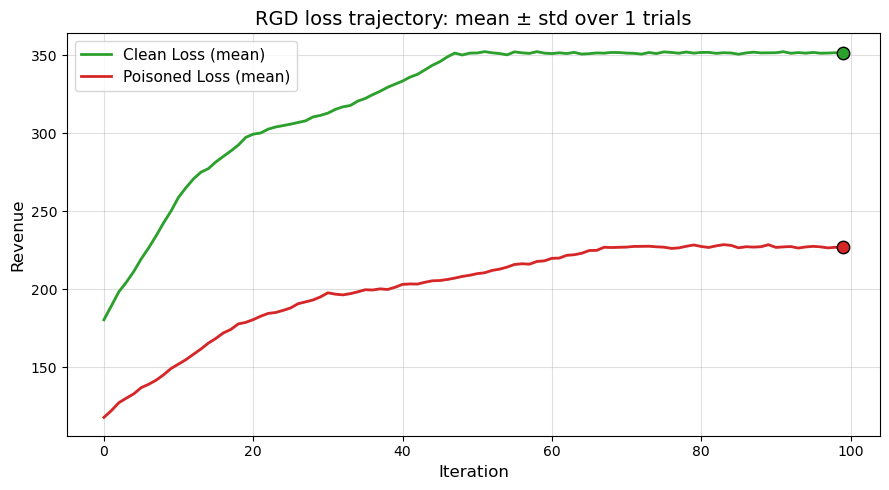

In [5]:
def pricing(mu_0: torch.Tensor = torch.Tensor([6.55,6.72,6.60,6.54,6.42]), 
            sigma: torch.Tensor = torch.eye(5), 
            eps: float = 1.5
    ):

    mu = lambda theta: mu_0 + eps * theta

    def D_theta(theta: torch.Tensor, n: int) -> torch.Tensor:
        return torch.distributions.MultivariateNormal(mu(theta), sigma).sample((n,)).T
    
    def loss(z: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
        return -torch.mean(theta.reshape(1, -1) @ z) 
    
    info = {"theta_optimal": mu_0 / (2 * eps), "theta_stable": mu_0 / eps}

    return D_theta, loss, mu, info

sigma = torch.eye(5)
n_trials = 1
eta = 0.01
n = 500
max_iter = 100

poison_kwargs = {
    'num_steps': 20,
    'step_size': 100,
    'epsilon': 5,
    'theta_update_estimator': theta_update_estimator,
    'sigma': sigma
}

D_theta, loss, mu, info = pricing(sigma=sigma)

def run_trial(theta_0):

    _, all_theta_clean, all_losses_clean = RGD(
        D_theta=D_theta,
        loss=loss,
        mu=mu,
        theta_0=theta_0.clone(),
        n=n,
        eta=eta,
        max_iter=max_iter,
        theta_min=0.0,
        theta_max=5.0,
        poison_function=None
    )
    _, all_theta_poisoned, all_losses_poisoned = RGD(
        D_theta=D_theta,
        loss=loss,
        mu=mu,
        theta_0=theta_0.clone(),
        n=n,
        eta=eta,
        max_iter=max_iter,
        theta_min=0.0,
        theta_max=5.0,
        poison_function=oracle_poison_function,
        **poison_kwargs
    )
    
    return all_losses_clean, all_losses_poisoned

all_losses_clean_list = []
all_losses_poisoned_list = []

for trial in range(n_trials):
    theta_0 = 5 * torch.rand(5)
    all_losses_clean, all_losses_poisoned = run_trial(theta_0=theta_0)
    all_losses_clean_list.append(all_losses_clean)
    all_losses_poisoned_list.append(all_losses_poisoned)

# Aggregate across trials and plot mean ± std for losses
def to_float_array_losses(traj):
    return torch.tensor([t.item() if hasattr(t, "item") else float(t) for t in traj], dtype=torch.float32)

clean_stack = torch.stack([to_float_array_losses(traj) for traj in all_losses_clean_list])      # [n_trials, T]
poison_stack = torch.stack([to_float_array_losses(traj) for traj in all_losses_poisoned_list])  # [n_trials, T]

clean_mean = -clean_stack.mean(dim=0).numpy()
clean_std  = clean_stack.std(dim=0, unbiased=False).numpy()
poison_mean = -poison_stack.mean(dim=0).numpy()
poison_std  = poison_stack.std(dim=0, unbiased=False).numpy()

x = np.arange(clean_mean.shape[0])

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(x, clean_mean, label='Clean Loss (mean)', color='tab:green', linewidth=2)
ax.fill_between(x, clean_mean - clean_std, clean_mean + clean_std, color='tab:green', alpha=0.2)

ax.plot(x, poison_mean, label='Poisoned Loss (mean)', color='tab:red', linewidth=2)
ax.fill_between(x, poison_mean - poison_std, poison_mean + poison_std, color='tab:red', alpha=0.2)

ax.scatter(x[-1], clean_mean[-1], color='tab:green', edgecolor='k', s=80, zorder=5)
ax.scatter(x[-1], poison_mean[-1], color='tab:red', edgecolor='k', s=80, zorder=5)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Revenue', fontsize=12)
ax.set_title(f'RGD loss trajectory: mean ± std over {clean_stack.shape[0]} trials', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# Binary Classification Example

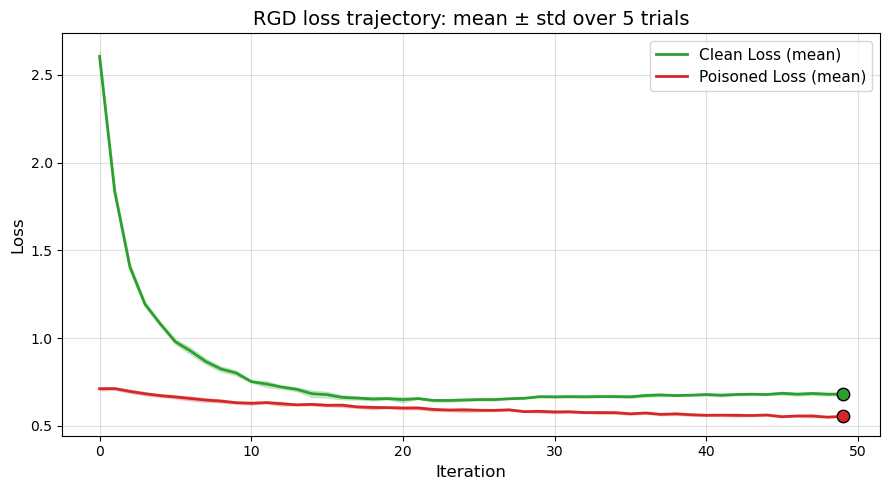

In [15]:
def binary_classification(
            mu_0: torch.Tensor = torch.tensor([1.0]), 
            mu_1: torch.Tensor = torch.tensor([-1.0]),
            sigma_0: float = 0.25,
            sigma_1: float = 0.25, 
            eps: float = 3,
            Lambda: float = 0.01
    ):

    mu_f = lambda theta: mu_1 - eps * theta[1]

    def D_theta(theta: torch.Tensor, n: int) -> torch.Tensor:
        y = torch.randint(low=0, high=2, size=(n,), dtype=torch.int32)
        x_1 = mu_f(theta).unsqueeze(-1) + torch.sqrt(sigma_1) * torch.randn((n))
        x_0 = mu_0.unsqueeze(-1) + torch.sqrt(sigma_0) * torch.randn((n))
        x = torch.where(y.unsqueeze(0) == 1, x_1, x_0)
        z = torch.vstack((x, y.float()))
        return z

    def loss(z: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
        theta_0 = theta[0]
        theta_1 = theta[1]
        x = z[0, :]
        y = z[1, :]
        h = 1 / (1 + torch.exp(-(theta_0 + theta_1 * x)))
        loss = -y * torch.log(h) - (1 - y) * torch.log(1 - h) + (Lambda / 2) * torch.sum(theta**2)
        return loss.mean() 
    
    return D_theta, loss, mu_f


def oracle_poison_function(
    z: torch.Tensor, 
    theta: torch.Tensor, 
    theta_update_estimator: Callable,
    mu_f: Callable,
    mu_0: torch.Tensor,
    sigma_0: torch.Tensor,
    sigma_1: torch.Tensor,
    loss: Callable,
    eta: float,
    num_steps: int = 10, 
    step_size: float = 0.1, 
    epsilon: float = 1e-6,
    norm = 'linf', # 'l2' or 'linf'
    ):
    
    z_0 = z.clone().detach()
    for _ in range(num_steps): 
       
        z.requires_grad_(True)
        z.grad = None
        theta_new = theta_update_estimator(z, theta, eta, loss)
        assert theta_new.shape == theta.shape, "Shape mismatch in theta update estimator."

        mu_new = mu_f(theta_new)
        
        y_new = torch.randint(low=0, high=2, size=(n,), dtype=torch.int32)
        x_1_new = mu_new.unsqueeze(-1) + torch.sqrt(sigma_1) * torch.randn(n)
        x_0_new = mu_0.unsqueeze(-1) + torch.sqrt(sigma_0) * torch.randn(n)
        x_new = torch.where(y_new.unsqueeze(0) == 1, x_1_new, x_0_new)
        z_new = torch.vstack((x_new, y_new.float()))

        assert z_new.shape == z.shape, f"Shape mismatch in z_new: expected {z.shape}, got {z_new.shape}."
        
        l_theta = loss(z_new, theta_new)
        
        l_theta.backward()
        dz = z.grad
        
        with torch.no_grad():
            z += step_size * dz / (torch.norm(dz, dim=0, keepdim=True) + 1e-16)
            delta = z - z_0
            if norm == 'l2':
                delta_norm = torch.norm(delta, p=2, dim=0, keepdim=True) + 1e-16
                exceed_mask = (delta_norm > epsilon).float()
                delta = delta * (epsilon / delta_norm) * exceed_mask + delta * (1 - exceed_mask)
            elif norm == 'linf':
                delta_norm = torch.max(torch.abs(delta), dim=0, keepdim=True)[0] + 1e-16
                exceed_mask = (delta_norm > epsilon).float()
                delta = delta * (epsilon / delta_norm) * exceed_mask + delta * (1 - exceed_mask)
            assert delta.shape == z.shape, f"Shape mismatch in delta: expected {z.shape}, got {delta.shape}."
            z = z_0 + delta
            
    return z.detach()

mu_0: torch.Tensor = torch.tensor([1.0]) 
mu_1: torch.Tensor = torch.tensor([-1.0])
sigma_0: float = torch.tensor(0.25)
sigma_1: float = torch.tensor(0.25)
eps: float = 3
Lambda: float = 0.01

n_trials = 5
eta = 0.1
n = 500
max_iter = 50


D_theta, loss, mu_f = binary_classification(
    mu_0=mu_0, 
    mu_1=mu_1,  
    sigma_0=sigma_0, 
    sigma_1=sigma_1, 
    eps=eps, 
    Lambda=Lambda
)

poison_kwargs = {
    'num_steps': 20,
    'step_size': 0.1,
    'epsilon': 0.8,
    'theta_update_estimator': theta_update_estimator,
    "mu_f": mu_f,
    "mu_0": mu_0,
    "sigma_0": sigma_0,
    "sigma_1": sigma_1,
}

def run_trial(theta_0):

    _, all_theta_clean, all_losses_clean = RGD(
        D_theta=D_theta,
        loss=loss,
        theta_0=theta_0.clone(),
        n=n,
        eta=eta,
        max_iter=max_iter,
        poison_function=None
    )
    _, all_theta_poisoned, all_losses_poisoned = RGD(
        D_theta=D_theta,
        loss=loss,
        theta_0=theta_0.clone(),
        n=n,
        eta=eta,
        max_iter=max_iter,
        poison_function=oracle_poison_function,
        **poison_kwargs
    )
    
    return all_losses_clean, all_losses_poisoned

all_losses_clean_list = []
all_losses_poisoned_list = []

for trial in range(n_trials):
    theta_0 = torch.tensor([1.0,1])
    all_losses_clean, all_losses_poisoned = run_trial(theta_0=theta_0)
    all_losses_clean_list.append(all_losses_clean)
    all_losses_poisoned_list.append(all_losses_poisoned)

# Aggregate across trials and plot mean ± std for losses
def to_float_array_losses(traj):
    return torch.tensor([t.item() if hasattr(t, "item") else float(t) for t in traj], dtype=torch.float32)

clean_stack = torch.stack([to_float_array_losses(traj) for traj in all_losses_clean_list])      # [n_trials, T]
poison_stack = torch.stack([to_float_array_losses(traj) for traj in all_losses_poisoned_list])  # [n_trials, T]

clean_mean = clean_stack.mean(dim=0).numpy()
clean_std  = clean_stack.std(dim=0, unbiased=False).numpy()
poison_mean = poison_stack.mean(dim=0).numpy()
poison_std  = poison_stack.std(dim=0, unbiased=False).numpy()

x = np.arange(clean_mean.shape[0])

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(x, clean_mean, label='Clean Loss (mean)', color='tab:green', linewidth=2)
ax.fill_between(x, clean_mean - clean_std, clean_mean + clean_std, color='tab:green', alpha=0.2)

ax.plot(x, poison_mean, label='Poisoned Loss (mean)', color='tab:red', linewidth=2)
ax.fill_between(x, poison_mean - poison_std, poison_mean + poison_std, color='tab:red', alpha=0.2)

ax.scatter(x[-1], clean_mean[-1], color='tab:green', edgecolor='k', s=80, zorder=5)
ax.scatter(x[-1], poison_mean[-1], color='tab:red', edgecolor='k', s=80, zorder=5)

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title(f'RGD loss trajectory: mean ± std over {clean_stack.shape[0]} trials', fontsize=14)
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# PerfGD

In [7]:
import torch
from typing import Callable, Optional
import numpy as np
import matplotlib.pyplot as plt

def PerfGD(
    f_hat: Callable,
    grad2_est: Callable,
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    proj_theta: Callable = lambda x: x,
    n: int = 500,
    eta: float = 0.1,
    tol: float = 1e-5,
    max_iter: int = 30,
    poison_function: Optional[Callable] = None,
    **poison_kwargs
):
    
    all_thetas = [theta_0]
    all_losses = []

    # Use unlimited history instead of fixed H
    theta_history = []
    f_history = []

    # Take only 1 step of RGD for initialization
    theta_t = theta_0
    z = D_theta(theta_t, n) # Draw n samples from D(theta)

    if poison_function is not None:
        z = poison_function(z, theta_t, loss=loss, eta=eta, theta_history=theta_history, f_history=f_history, grad2_est=grad2_est, **poison_kwargs)

    f_t = f_hat(z)  # Estimate for f(theta)

    theta_history.append(theta_t.detach())
    f_history.append(f_t.detach())

    # One gradient descent step on Loss_1 loss
    theta_t.requires_grad_(True)
    theta_t.grad = None 
    l_t = loss(z, theta_t).mean(dim=-1)
    l_t.backward()
    dL1 = theta_t.grad

    with torch.no_grad():
        theta_t = proj_theta(theta_t - eta * dL1)

    all_thetas.append(theta_t.detach().squeeze())

    # Now run with full gradient update using entire history
    converged = False
    t = 1
    while not converged:

        z = D_theta(theta_t, n) # Draw n samples from D(theta) (d x n)

        if poison_function is not None:
            z = poison_function(z, theta_t, loss=loss, eta=eta, theta_history=theta_history, f_history=f_history, grad2_est=grad2_est, **poison_kwargs)

        f_t = f_hat(z) # (d,)
        
        theta_history.append(theta_t.detach())
        f_history.append(f_t.detach())

        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean(dim=-1)
        l_t.backward()
        dL1 = theta_t.grad
        
        # Use entire history (not just last H steps)
        if len(theta_history) >= 2:  # Need at least 2 points for gradient estimation
            Theta_full = torch.stack([th for th in theta_history], dim=1)   # (p, t+1)
            F_full = torch.stack([fh for fh in f_history], dim=1)   # (q, t+1)
            
            Theta = Theta_full[:, :-1]                                      # (p, t) -> 0 : t-1
            F = F_full[:, :-1]
            oneH = torch.ones(1, Theta.shape[1], device=Theta.device)

            delta_theta = Theta - theta_t.unsqueeze(1) @ oneH          # (p, t)
            delta_f = F - f_t.unsqueeze(1) @ oneH          # (q, t)

            df_d_theta = delta_f @ torch.linalg.pinv(delta_theta) # (p x q)

            dL2 = grad2_est(z, f_t, theta_t, df_d_theta)
        else:
            dL2 = torch.zeros_like(dL1)  # No performative correction if not enough history

        with torch.no_grad():
            theta_t = proj_theta(theta_t - eta * (dL1 + dL2))

        all_thetas.append(theta_t.detach().squeeze())

        z_true = D_theta(theta_t, n)
        true_loss = loss(z_true, theta_t).mean()
        all_losses.append(true_loss)
        
        if (dL1 + dL2).norm() < tol: 
            break # Converged
        
        t += 1
        if t > max_iter: 
            break # Max iterations
    
    return all_losses, all_thetas[2:]



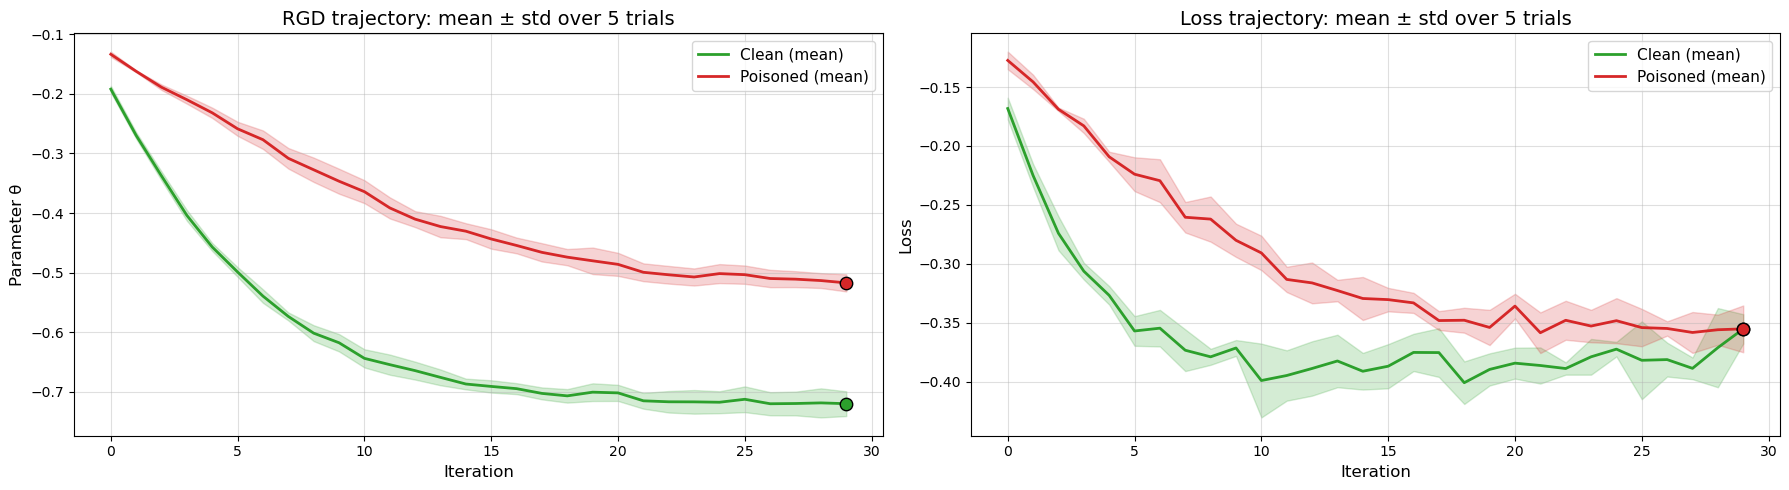

In [8]:
def oracle_poison_function(
    z: torch.Tensor, 
    theta: torch.Tensor, 
    theta_update_estimator: Callable,
    mu: Callable,
    sigma: torch.Tensor,
    loss: Callable,
    eta: float,
    num_steps: int = 10, 
    step_size: float = 0.1, 
    epsilon: float = 1e-6,
    norm = 'linf', # 'l2' or 'linf'
    theta_history: list = [],
    f_history: list = [],
    grad2_est: Callable = None
    ):
    
    z_0 = z.clone().detach()
    for _ in range(num_steps): 
       
        z.requires_grad_(True)
        z.grad = None

        theta_new = theta_update_estimator(z, theta, eta, loss, f_hat, theta_history, f_history, grad2_est)
        assert theta_new.shape == theta.shape, "Shape mismatch in theta update estimator."

        mu_new = mu(theta_new)
        assert mu_new.shape == z.shape[:1], f"Shape mismatch in mu function: expected {z.shape[0]}, got {mu_new.shape}."
        
        z_new = mu_new.unsqueeze(-1) + sigma @ torch.randn_like(z)
        assert z_new.shape == z.shape, f"Shape mismatch in z_new: expected {z.shape}, got {z_new.shape}."
        
        l_theta = loss(z_new, theta_new).mean()
        
        l_theta.backward()
        dz = z.grad
        
        with torch.no_grad():
            z += step_size * dz / (torch.norm(dz, dim=0, keepdim=True) + 1e-16)
            delta = z - z_0
            if norm == 'l2':
                delta_norm = torch.norm(delta, p=2, dim=0, keepdim=True) + 1e-16
                exceed_mask = (delta_norm > epsilon).float()
                delta = delta * (epsilon / delta_norm) * exceed_mask + delta * (1 - exceed_mask)
            elif norm == 'linf':
                delta_norm = torch.max(torch.abs(delta), dim=0, keepdim=True)[0] + 1e-16
                exceed_mask = (delta_norm > epsilon).float()
                delta = delta * (epsilon / delta_norm) * exceed_mask + delta * (1 - exceed_mask)
            assert delta.shape == z.shape, f"Shape mismatch in delta: expected {z.shape}, got {delta.shape}."
            z = z_0 + delta
            
    return z.detach()

def theta_update_estimator(z, theta, eta, loss, f_hat, theta_history, f_history, grad2_est):
    
    f_t = f_hat(z) # (d,)
    
    theta.requires_grad_(True)
    theta.grad = None
    l_t = loss(z, theta).mean()
    l_t.backward()
    dL1 = theta.grad

    # Use entire history (not just last H steps)
    if len(theta_history) >= 2:  # Need at least 2 points for gradient estimation
        Theta_full = torch.stack([th for th in theta_history], dim=1)   # (p, t+1)
        F_full = torch.stack([fh for fh in f_history], dim=1)   # (q, t+1)
        
        Theta = Theta_full[:, :-1]                                      # (p, t) -> 0 : t-1
        F = F_full[:, :-1]
        oneH = torch.ones(1, Theta.shape[1], device=Theta.device)

        delta_theta = Theta - theta.unsqueeze(1) @ oneH          # (p, t)
        delta_f = F - f_t.unsqueeze(1) @ oneH          # (q, t)

        df_d_theta = delta_f @ torch.linalg.pinv(delta_theta) # (p x q)

        dL2 = grad2_est(z, f_t, theta, df_d_theta)
    else:
        dL2 = torch.zeros_like(dL1)  # No performative correction if not enough history

    theta = proj_theta(theta - eta * (dL1 + dL2))

    return theta

a0 = 1.0
a1 = 1.0
sigma = torch.tensor([[1.0]])
mu = lambda theta: torch.sqrt(a0*theta + a1) # Define mean function (determines performativity)
f_hat = lambda z: z.mean(dim=1)
D_theta = lambda theta, n: torch.normal(mu(theta).squeeze(), 1.0, size=(1,n))
loss = lambda z, theta: (z*theta)
def grad2_est(z, f, theta, df_d_theta):
    if z.ndim == 1: z = z.unsqueeze(0)
    if f.ndim == 1: f = f.unsqueeze(0)
    return torch.mean( loss(z, theta) * (df_d_theta.T @ torch.linalg.inv(sigma) @ (z - f)), dim=-1)

proj_theta = lambda x: x.clamp(min=-1.0, max=1.0)

poison_kwargs = {
    'num_steps': 10,
    'step_size': 0.05,
    'epsilon': .3,
    'theta_update_estimator': theta_update_estimator,
    'mu': mu,
    'sigma': sigma,
}

n_trials = 5
n = 1000
max_iter = 30

def run_trial():

    all_losses_clean, all_theta_clean = PerfGD(
        f_hat,
        grad2_est,
        D_theta,
        loss,
        theta_0 = torch.tensor([0.0]),
        proj_theta = proj_theta,
        n = n,
        eta = 0.1,
        tol = 1e-5,
        max_iter = max_iter,
        poison_function=None
    )
 
    all_losses_poisoned, all_theta_poisoned = PerfGD(
                f_hat,
                grad2_est,
                D_theta,
                loss,
                theta_0 = torch.tensor([0.0]),
                proj_theta = proj_theta,
                n = n,
                eta = 0.1,
                tol = 1e-5,
                max_iter = max_iter,
                poison_function=oracle_poison_function,
                **poison_kwargs
            )
        

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

# Aggregate across trials and plot mean ± std
def to_float_array(traj):
    return torch.tensor([t.item() if hasattr(t, "item") else float(t) for t in traj], dtype=torch.float32)

clean_stack = torch.stack([to_float_array(traj) for traj in all_theta_clean_list])      # [n_trials, T]
poison_stack = torch.stack([to_float_array(traj) for traj in all_theta_poisoned_list])  # [n_trials, T]

clean_mean = clean_stack.mean(dim=0).numpy()
clean_std  = clean_stack.std(dim=0, unbiased=False).numpy()
poison_mean = poison_stack.mean(dim=0).numpy()
poison_std  = poison_stack.std(dim=0, unbiased=False).numpy()

# Also process loss trajectories
loss_clean_stack = torch.stack([to_float_array(traj) for traj in all_loss_clean_list])      # [n_trials, T]
loss_poison_stack = torch.stack([to_float_array(traj) for traj in all_loss_poisoned_list])  # [n_trials, T]

loss_clean_mean = loss_clean_stack.mean(dim=0).numpy()
loss_clean_std  = loss_clean_stack.std(dim=0, unbiased=False).numpy()
loss_poison_mean = loss_poison_stack.mean(dim=0).numpy()
loss_poison_std  = loss_poison_stack.std(dim=0, unbiased=False).numpy()

x = np.arange(clean_mean.shape[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,5))

# Plot parameter trajectories
ax1.plot(x, clean_mean, label='Clean (mean)', color='tab:green', linewidth=2)
ax1.fill_between(x, clean_mean - clean_std, clean_mean + clean_std, color='tab:green', alpha=0.2)

ax1.plot(x, poison_mean, label='Poisoned (mean)', color='tab:red', linewidth=2)
ax1.fill_between(x, poison_mean - poison_std, poison_mean + poison_std, color='tab:red', alpha=0.2)

ax1.scatter(x[-1], clean_mean[-1], color='tab:green', edgecolor='k', s=80, zorder=5)
ax1.scatter(x[-1], poison_mean[-1], color='tab:red', edgecolor='k', s=80, zorder=5)

ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Parameter θ', fontsize=12)
ax1.set_title(f'RGD trajectory: mean ± std over {clean_stack.shape[0]} trials', fontsize=14)
ax1.legend(loc='best', fontsize=11)
ax1.grid(alpha=0.4)

# Plot loss trajectories
ax2.plot(x, loss_clean_mean, label='Clean (mean)', color='tab:green', linewidth=2)
ax2.fill_between(x, loss_clean_mean - loss_clean_std, loss_clean_mean + loss_clean_std, color='tab:green', alpha=0.2)

ax2.plot(x, loss_poison_mean, label='Poisoned (mean)', color='tab:red', linewidth=2)
ax2.fill_between(x, loss_poison_mean - loss_poison_std, loss_poison_mean + loss_poison_std, color='tab:red', alpha=0.2)

ax2.scatter(x[-1], loss_clean_mean[-1], color='tab:green', edgecolor='k', s=80, zorder=5)
ax2.scatter(x[-1], loss_poison_mean[-1], color='tab:red', edgecolor='k', s=80, zorder=5)

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title(f'Loss trajectory: mean ± std over {clean_stack.shape[0]} trials', fontsize=14)
ax2.legend(loc='best', fontsize=11)
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()